# <font color="dodgerblue">Exploratory Data Analysis of YouTube Comments</font>

This notebook documents the exploratory analysis that supports the data slides in the accompanying presentation and precedes the modeling workflow in `sentiment_analysis.ipynb`.

## *<font color="gray">Summary</font>*

- Source dataset: 1,032,225 labeled YouTube comments.
- Analysis sample: deterministic 100,000-row sample using `random_state=42`.
- Sentiment classes are balanced at approximately one third each.
- Average comment length is **19.23 words**; Negative comments are longer on average.
- **21.1%** of sampled comments contain at least one detected emoji.

The displayed charts and tables are preserved from the completed Colab analysis used to prepare the PDF.

## Context 

The goal is to understand the raw text before translation or model-specific preprocessing. The notebook examines class balance, comment length, frequent words, and emoji usage.

### Key assumptions

- The dataset labels combine automated labeling and manual validation.
- The source dataset includes augmented comments intended to improve class balance.
- Word clouds are descriptive views of raw word frequency (they do not represent feature importance).
- Emoji runs such as `😂😂😂` are counted as observed sequences in the final table, matching the original analysis.

## 1. Setup

Install dependencies from the repository root with:

```bash
python -m pip install -r requirements.txt
```

The source dataset is public. No Hugging Face token is embedded or required.

In [ ]:
from __future__ import annotations

import hashlib
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from huggingface_hub import hf_hub_download
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SEED = 42
SAMPLE_SIZE = 100_000
DATASET_REPO = "AmaanP314/youtube-comment-sentiment"
DATASET_FILENAME = "youtube-comments-sentiment.csv"
DATASET_SHA256 = "368b41f5675f0bd2313ab41c7f524489c54cb8792e31e24a87091c70c118c3fe"

COLORS = {
    "Negative": "#ff0000",
    "Neutral": "#2c7ef7",
    "Positive": "#82fe7b",
}
PLOT_ORDER = ["Negative", "Positive", "Neutral"]

## 2. Load the deterministic sample

Source: [YouTube Comments Sentiment Analysis Dataset](https://huggingface.co/datasets/AmaanP314/youtube-comment-sentiment). The checksum prevents the translation and modeling notebooks from silently using a different source file.

In [ ]:
dataset_path = Path(
    hf_hub_download(
        repo_id=DATASET_REPO,
        filename=DATASET_FILENAME,
        repo_type="dataset",
    )
)

hasher = hashlib.sha256()
with dataset_path.open("rb") as dataset_file:
    for chunk in iter(lambda: dataset_file.read(1024 * 1024), b""):
        hasher.update(chunk)
if hasher.hexdigest() != DATASET_SHA256:
    raise ValueError("The downloaded dataset does not match the version used in this project.")

source_df = pd.read_csv(dataset_path)
df = (
    source_df[["CommentText", "Sentiment"]]
    .sample(SAMPLE_SIZE, random_state=SEED)
    .copy()
)

print(f"Source rows: {len(source_df):,}")
print(f"Sample rows: {len(df):,}")
display(df.head(3))

Source rows: 1,032,225
Sample rows: 100,000


,CommentText,Sentiment
986142,This video was quite hard to follow and unders...,Negative
865071,Love your show ❤️ 🤍💙 and appreciate your coura...,Positive
991085,what color theme do you use \nPlease tell me,Neutral


## 3. Comment length

In [ ]:
df["length"] = df["CommentText"].fillna("").str.split().str.len()

quantiles = [0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
length_statistics = (
    df.groupby("Sentiment")["length"]
    .describe(percentiles=quantiles)
    .round(2)
)
length_statistics["median"] = df.groupby("Sentiment")["length"].median()
length_statistics

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max,median
Sentiment,,,,,,,,,,,,
Negative,33435.0,22.62,34.74,1.0,3.0,8.0,14.0,26.0,66.0,147.0,1758.0,14.0
Neutral,33282.0,16.44,28.67,0.0,1.0,5.0,10.0,18.0,50.0,109.0,1518.0,10.0
Positive,33283.0,18.64,24.76,1.0,2.0,6.0,12.0,22.0,57.0,115.0,896.0,12.0


The weighted mean is **19.23 words per comment**. Negative comments are longest on average (22.62 words), followed by Positive (18.64) and Neutral (16.44). The maximum values are much larger than the medians, so the distribution is strongly right-skewed.

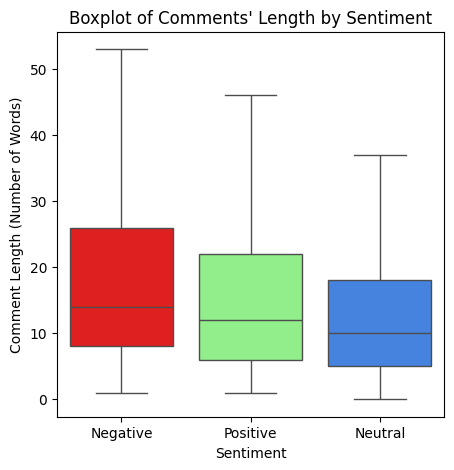

In [ ]:
plt.figure(figsize=(5, 5))
sns.boxplot(
    data=df,
    x="Sentiment",
    y="length",
    order=PLOT_ORDER,
    hue="Sentiment",
    hue_order=PLOT_ORDER,
    palette=COLORS,
    showfliers=False,
    legend=False,
)
plt.xlabel("Sentiment")
plt.ylabel("Comment Length (Number of Words)")
plt.title("Boxplot of Comments' Length by Sentiment")
plt.tight_layout()
plt.show()

## 4. Sentiment distribution

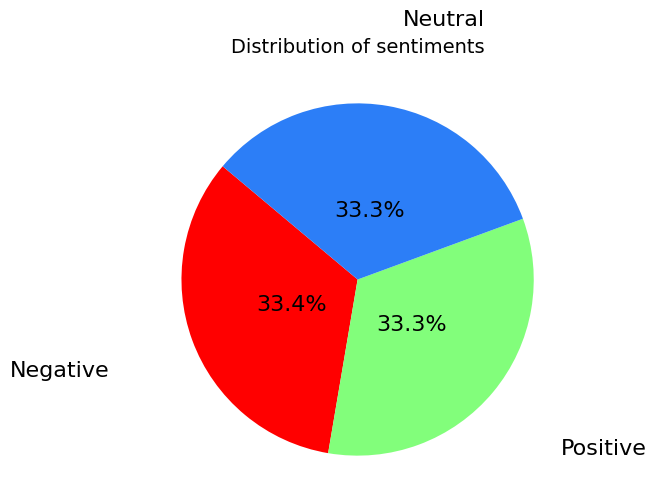

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()
pie_colors = [COLORS[label] for label in sentiment_counts.index]

plt.figure(figsize=(5, 5))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    labeldistance=1.5,
    pctdistance=0.4,
    textprops={"fontsize": 16, "color": "black"},
)
plt.title("Distribution of sentiments", fontsize=14, pad=25)
plt.axis("equal")
plt.show()

The deterministic sample is effectively balanced: 33,435 Negative, 33,283 Positive, and 33,282 Neutral comments.

## 5. Raw word frequency

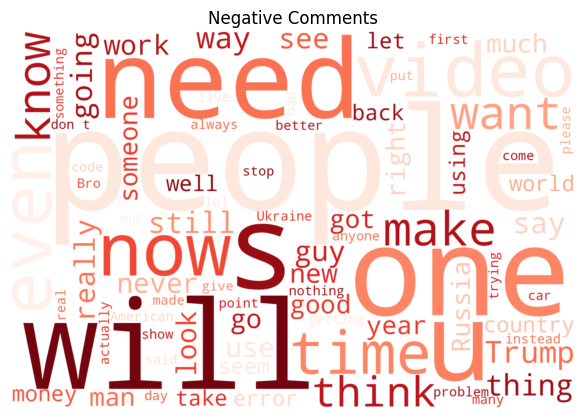

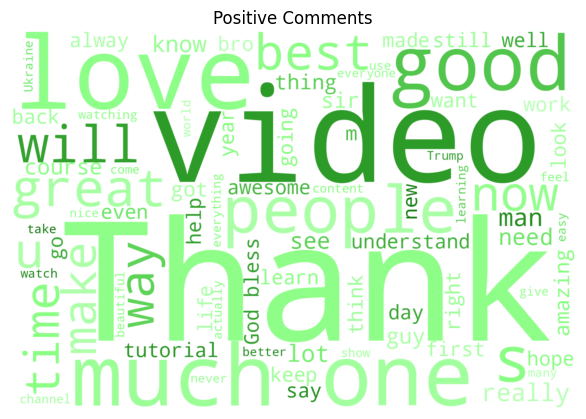

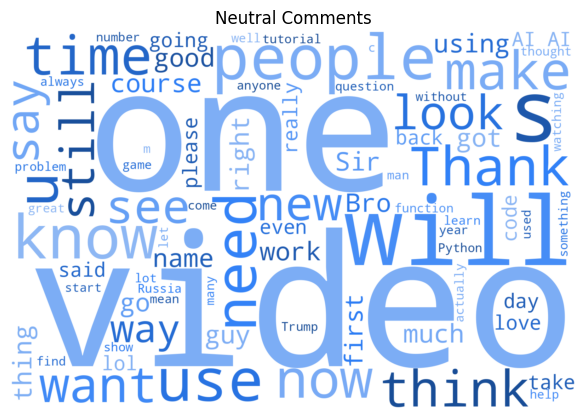

In [ ]:
neutral_cmap = LinearSegmentedColormap.from_list(
    "neutral", ["#8fb8f4", "#2c7ef7", "#184c95"]
)
positive_cmap = LinearSegmentedColormap.from_list(
    "positive", ["#baffb7", "#82fe7b", "#097105"]
)

wordcloud_cmaps = {
    "Negative": "Reds",
    "Positive": positive_cmap,
    "Neutral": neutral_cmap,
}

for sentiment in PLOT_ORDER:
    text = " ".join(df.loc[df["Sentiment"] == sentiment, "CommentText"].astype(str))
    wordcloud = WordCloud(
        width=600,
        height=400,
        scale=3,
        max_words=80,
        background_color="white",
        colormap=wordcloud_cmaps[sentiment],
    ).generate(text)

    plt.figure(figsize=(6, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{sentiment} Comments")
    plt.tight_layout(pad=0)
    plt.show()

These word clouds use raw, unprocessed comments to illustrate frequent vocabulary. Stopwords and repeated generic terms remain visible by design, so the charts should not be interpreted as explanations of the model.

## 6. Emoji usage

In [ ]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)


def has_emoji(text: object) -> bool:
    return bool(EMOJI_PATTERN.search("" if pd.isna(text) else str(text)))


emoji_presence = df["CommentText"].apply(has_emoji).value_counts()
emoji_presence

,count
CommentText,
False,78906
True,21094


**21,094 comments (21.1%)** contain at least one detected emoji.

In [ ]:
def extract_emoji_sequences(text: object) -> list[str]:
    return EMOJI_PATTERN.findall("" if pd.isna(text) else str(text))


for sentiment in df["Sentiment"].unique():
    emoji_sequences = (
        df.loc[df["Sentiment"] == sentiment, "CommentText"]
        .apply(extract_emoji_sequences)
        .explode()
        .dropna()
    )
    sequence_counts = Counter(emoji_sequences)
    print(f"Top emoji sequences for {sentiment} sentiment:")
    for sequence, count in sequence_counts.most_common(6):
        print(f"{sequence}: {count}")
    print()

Top emoji sequences for Negative sentiment:
😂: 796
😢: 439
😂😂😂: 213
💀: 199
😭: 190
😅: 164


Top emoji sequences for Positive sentiment:
❤: 1405
😂: 731
😊: 365
❤❤❤: 269
👍: 267
❤️: 235


Top emoji sequences for Neutral sentiment:
😂: 1040
😅: 363
🗿: 308
😂😂: 258
😂😂😂: 239
💀: 198




## Takeaways

- The sample is balanced by sentiment, consistent with the source dataset's augmentation strategy.
- Comment lengths are right-skewed. Therefore, medians are more representative than maxima.
- Negative comments are longer on average than Positive and Neutral comments.
- Emoji use is common across all three classes and can be sentiment-dependent, supporting the decision to convert emojis to text before modeling.
- The modeling notebook performs language detection and selective translation, this notebook intentionally focuses on raw exploratory analysis.